# Heart Disease Dataset

## Resumo

O conjunto de dados analisado reúne informações clínicas relacionadas à saúde cardiovascular de pacientes, com foco na identificação da presença de doenças cardíacas. O dataset é amplamente utilizado em estudos de aprendizado de máquina e análise preditiva na área da saúde.

Ele contém variáveis médicas e fisiológicas, como idade, sexo, pressão arterial, colesterol, frequência cardíaca máxima atingida e resultados de exames cardíacos, permitindo compreender fatores associados ao desenvolvimento de doenças do coração.

Além disso, o conjunto de dados inclui informações obtidas durante testes clínicos, como angina induzida por exercício físico, alterações no segmento ST e resultados de eletrocardiogramas, possibilitando análises detalhadas sobre o estado cardiovascular dos pacientes.

Em conjunto, esses dados permitem uma análise exploratória completa, auxiliando na identificação de padrões, fatores de risco e características relevantes para a predição de doenças cardíacas.

## Introdução e Contextualização

Heart Disease Dataset é um conjunto de dados criado em 1988 e composto por informações clínicas provenientes de quatro bases de dados: Cleveland, Hungary, Switzerland e Long Beach V. O dataset contém originalmente 76 atributos, porém os estudos publicados utilizam um subconjunto com 14 variáveis principais.

O objetivo principal do conjunto de dados é identificar a presença de doença cardíaca em pacientes. A variável alvo é target, onde 0 representa ausência de doença cardíaca e 1 representa presença de doença cardíaca.

As principais variáveis preditoras (features) incluem: age, sex, cp (tipo de dor no peito), trestbps (pressão arterial em repouso), chol (colesterol sérico), thalach (frequência cardíaca máxima atingida), exang (angina induzida por exercício), oldpeak (depressão do segmento ST) e thal (resultado de exame cardíaco).

Os dados pessoais dos pacientes, como nomes e números de seguridade social, foram removidos da base e substituídos por valores fictícios, garantindo maior privacidade e anonimização das informações.

## Objetivos do Projeto

O objetivo é realizar uma análise comparativa entre diferentes abordagens de classificação para prever a presença de doença cardíaca em pacientes, identificando qual modelo apresenta o melhor desempenho e capacidade de generalização.

Além disso, busca-se compreender quais variáveis possuem maior influência na predição da doença, analisando padrões clínicos e fatores de risco associados às condições cardiovasculares.

## Tratamento e Limpeza dos Dados
Etapa de preparo dos dados brutos para que possam ser analisados de forma confiável. Ou seja, é onde transforma um conjunto de dados “bagunçado” em algo consistente, estruturado e utilizável.

In [77]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [78]:
heart_disease_df = pd.read_csv("heart.csv")
heart_disease_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [79]:
heart_disease_df.shape

(1025, 14)

In [80]:
heart_disease_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [81]:
heart_disease_df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [82]:
heart_disease_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


#### CONCLUSÃO DO TRATAMENTO E LIMPEZA DOS DADOS
O dataset não possui valores nulos e todas as colunas apresentadas são passíveis de análise para a coluna alvo "target".

## Análise Exploratória (EDA)

A Análise Exploratória de Dados (EDA) é a etapa inicial de um processo de análise de dados cujo principal objetivo é compreender melhor o conjunto de dados antes de aplicar modelos estatísticos ou tomar decisões. Nessa fase, será investigado a estrutura, a qualidade e os padrões presentes nos dados, utilizando técnicas estatísticas e visuais. A EDA permite identificar problemas como dados faltantes, valores inconsistentes ou discrepantes (outliers), além de possibilitar uma visão geral do comportamento das variáveis.

### Distribuição da Variável Alvo
A distribuição da variável alvo refere-se à forma como os valores da variável estão organizados dentro de um conjunto de dados. A variável alvo, também chamada de variável dependente, é aquela que representa o resultado principal do estudo.

In [83]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


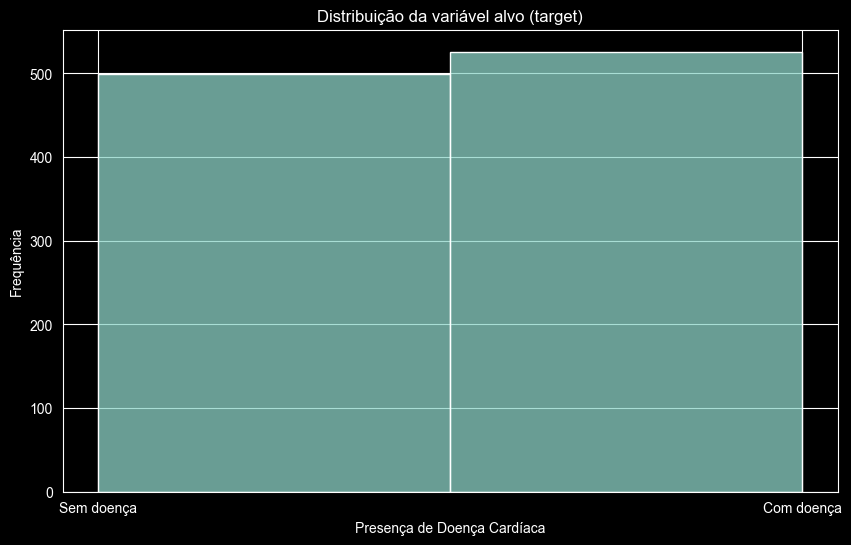

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))

sns.histplot(
    heart_disease_df['target'],
    bins=2,
    kde=False
)

plt.title('Distribuição da variável alvo (target)')
plt.xlabel('Presença de Doença Cardíaca')
plt.ylabel('Frequência')

plt.xticks([0, 1], ['Sem doença', 'Com doença'])

plt.show()

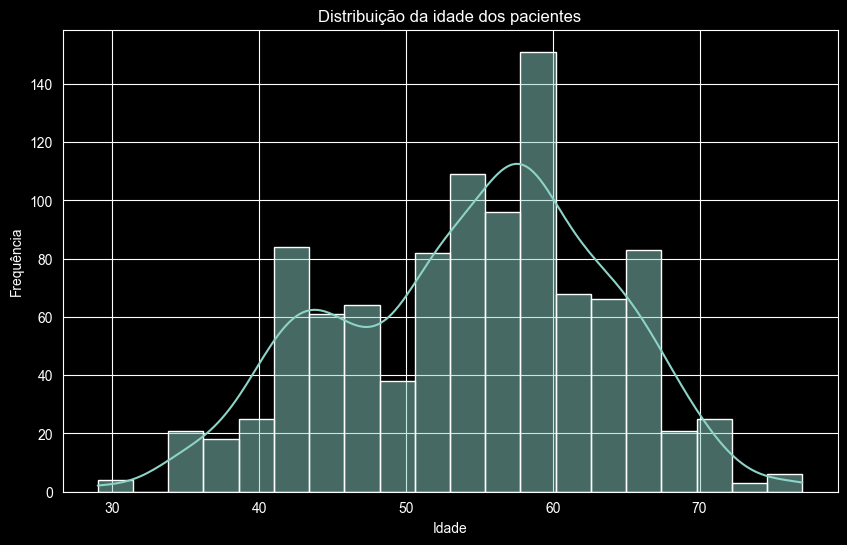

In [85]:
plt.figure(figsize=(10,6))

sns.histplot(
    heart_disease_df['age'],
    bins=20,
    kde=True
)

plt.title('Distribuição da idade dos pacientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.show()

#### CONCLUSÃO DA VARIÁVEL ALVO
A variável dependente target apresenta uma distribuição relativamente equilibrada entre pacientes com e sem doença cardíaca, indicando que o dataset possui boa representatividade para ambas as classes. Isso é importante para evitar vieses durante o treinamento dos modelos de classificação.

Como a variável alvo é binária (0 = sem doença cardíaca e 1 = com doença cardíaca), não foi necessária a aplicação de transformações, como a logarítmica, utilizada em problemas de regressão contínua. A distribuição observada é adequada para análises estatísticas e para o treinamento de algoritmos de classificação supervisionada.

### Outliers
Outliers são valores que fogem muito do padrão geral dos dados. Em uma Análise Exploratória de Dados (EDA), eles aparecem como observações extremamente altas ou baixas quando comparadas com a maioria dos outros valores do conjunto.
Em outras palavras, são pontos “fora da curva”. Identificar outliers é importante porque eles podem ter diferentes significados, podem influenciar bastante a análise, especialmente medidas como a média, podendo distorcer resultados e interpretações.

In [86]:
!pip install nbformat
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
import plotly.express as px

fig_box = px.box(
    heart_disease_df,
    x="target",
    y="chol",
    title="Detecção de Outliers: Colesterol por Presença de Doença Cardíaca",
    points="all",
    labels={
        "target": "Doença Cardíaca",
        "chol": "Colesterol (mg/dl)"
    }
)

fig_box.update_xaxes(
    tickvals=[0, 1],
    ticktext=["Sem doença", "Com doença"]
)

fig_box.show()

In [88]:
fig_box = px.box(
    heart_disease_df,
    x="target",
    y="age",
    title="Detecção de Outliers: Idade por Presença de Doença Cardíaca",
    points="all",
    labels={
        "target": "Doença Cardíaca",
        "age": "Idade"
    }
)

fig_box.update_xaxes(
    tickvals=[0, 1],
    ticktext=["Sem doença", "Com doença"]
)

fig_box.show()

In [89]:
fig_box = px.box(
    heart_disease_df,
    x="target",
    y="thalach",
    title="Detecção de Outliers: Frequência Cardíaca Máxima por Presença de Doença Cardíaca",
    points="all",
    labels={
        "target": "Doença Cardíaca",
        "thalach": "Frequência Cardíaca Máxima"
    }
)

fig_box.update_xaxes(
    tickvals=[0, 1],
    ticktext=["Sem doença", "Com doença"]
)

fig_box.show()

#### Conclusão de Outliers
Os outliers foram identificados nas variáveis numéricas do dataset, especialmente em atributos como colesterol (chol), pressão arterial em repouso (trestbps) e frequência cardíaca máxima (thalach). Esses valores extremos representam condições clínicas reais dos pacientes e, portanto, foram mantidos na análise.

Como o conjunto de dados pertence à área da saúde, a remoção indiscriminada desses valores poderia comprometer informações importantes relacionadas a casos mais graves ou incomuns de doenças cardíacas. Dessa forma, os outliers foram preservados para manter a representatividade e a integridade dos dados durante o treinamento dos modelos de classificação.

### Correlação
Correlação é uma medida que indica o quanto duas variáveis estão relacionadas entre si, ou seja, se quando uma muda, a outra tende a mudar também.

In [90]:
import plotly.express as px

# Seleciona apenas colunas numéricas
heart_df_num = heart_disease_df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlação
corr_matrix = heart_df_num.corr()

# Heatmap interativo
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    aspect="auto",
    title="Matriz de Correlação Interativa - Heart Disease Dataset"
)

fig.show()

#### Conclusão da Correlação
As variáveis que apresentaram maior influência na variável alvo target foram cp (tipo de dor no peito), thalach (frequência cardíaca máxima atingida), oldpeak (depressão do segmento ST) e exang (angina induzida por exercício), demonstrando correlações moderadas com a presença de doença cardíaca.

Algumas variáveis clínicas, como colesterol (chol) e glicemia em jejum (fbs), apresentaram baixa correlação linear com a variável alvo quando analisadas isoladamente. Além disso, certas variáveis possuem correlação entre si, indicando possíveis relações fisiológicas entre os indicadores cardíacos.

De forma geral, o dataset apresenta correlações lineares moderadas, sugerindo que a previsão da presença de doença cardíaca depende da combinação de múltiplos fatores clínicos e não apenas de uma única variável isolada.

## Pré-processamento e Engenharia de Features

### Tratamento de Variáveis Categóricos
O dataset Heart Disease possui variáveis categóricas representadas numericamente, como cp (tipo de dor no peito), restecg (resultado do eletrocardiograma), thal (resultado do exame cardíaco) e slope (inclinação do segmento ST). Apesar de estarem codificadas em números, essas variáveis representam categorias e não valores contínuos.

Para evitar que os algoritmos interpretassem essas categorias como relações ordinais, foi aplicado o processo de One-Hot Encoding, transformando cada categoria em colunas binárias independentes. Essa abordagem melhora o desempenho de modelos sensíveis à interpretação numérica das variáveis categóricas.

As variáveis binárias, como sex, fbs e exang, foram mantidas em seu formato original, pois já estavam adequadas para os modelos de classificação.

In [91]:
X = heart_disease_df.drop('target', axis=1)

y = heart_disease_df['target']

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(717, 13)
(308, 13)


### Escalonamento dos Dados

Foi utilizada a técnica de Padronização (StandardScaler) para normalizar os dados numéricos. Esse processo transforma as variáveis para que possuam média igual a 0 e desvio padrão igual a 1.

O escalonamento foi necessário porque algoritmos como:

KNN (K-Nearest Neighbors)
SVM (Support Vector Machine)
Regressão Logística

são altamente sensíveis à escala das variáveis. Sem a padronização, atributos com valores maiores, como colesterol (chol) e pressão arterial (trestbps), poderiam influenciar excessivamente o treinamento dos modelos.

A padronização também contribuiu para melhorar a convergência dos algoritmos e reduzir problemas relacionados à diferença de magnitude entre as features.

In [93]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Divisão dos Dados

O conjunto de dados foi dividido em:

70% para treinamento
30% para teste

Foi utilizado o parâmetro stratify=y durante a divisão para manter a proporção original das classes da variável alvo (target) nos conjuntos de treino e teste.

Essa abordagem garante uma distribuição equilibrada entre pacientes com e sem doença cardíaca, evitando vieses na avaliação dos modelos.

### Treinamento e Ajuste de Hiperparâmetros

Para reduzir riscos de overfitting e melhorar a capacidade de generalização dos modelos, foi utilizada a técnica de Cross-Validation durante o treinamento.

A validação cruzada permite dividir os dados de treinamento em múltiplas partes, treinando e validando o modelo diversas vezes em subconjuntos diferentes dos dados. Isso proporciona uma avaliação mais confiável do desempenho dos algoritmos.

Também foi realizado ajuste de hiperparâmetros para otimizar cada modelo, utilizando técnicas como:

Escolha do melhor número de vizinhos no KNN
Ajuste do parâmetro C e kernels no SVM
Controle da profundidade em Árvores de Decisão
Quantidade de árvores no Random Forest

O objetivo foi encontrar configurações que maximizassem a performance sem comprometer a generalização dos modelos.

## Implementação dos Algoritmos
### KNN (K-Nearest Neighbors)

O algoritmo KNN foi utilizado para classificar pacientes com base nos vizinhos mais próximos no espaço das variáveis. Foram realizados testes com diferentes valores de k para identificar a quantidade ideal de vizinhos e avaliar o impacto dessa escolha no desempenho do modelo.

In [94]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

params_knn = {
    'n_neighbors': range(1,21)
}

grid_knn = GridSearchCV(
    knn,
    params_knn,
    cv=5
)

grid_knn.fit(
    X_train_scaled,
    y_train
)

best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_scaled)

print("KNN")
print(classification_report(y_test, y_pred_knn))

KNN
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       150
           1       1.00      0.98      0.99       158

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308



### Regressão Logística

A Regressão Logística foi utilizada como modelo baseline estatístico devido à sua simplicidade e interpretabilidade. Esse modelo permite analisar a relação entre as variáveis clínicas e a probabilidade de presença de doença cardíaca.

In [95]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(
    X_train_scaled,
    y_train
)

y_pred_log = log_reg.predict(X_test_scaled)

print("Regressão Logística")
print(classification_report(y_test, y_pred_log))

Regressão Logística
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       150
           1       0.78      0.89      0.83       158

    accuracy                           0.82       308
   macro avg       0.83      0.82      0.82       308
weighted avg       0.82      0.82      0.82       308



### Árvore de Decisão

A Árvore de Decisão foi aplicada para capturar relações não-lineares entre as variáveis do dataset. Esse modelo também facilita a interpretação das decisões tomadas durante a classificação.

In [96]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Árvore de Decisão")
print(classification_report(y_test, y_pred_tree))

Árvore de Decisão
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       150
           1       0.84      0.92      0.88       158

    accuracy                           0.87       308
   macro avg       0.88      0.87      0.87       308
weighted avg       0.88      0.87      0.87       308



### Random Forest

O Random Forest foi utilizado como uma evolução das Árvores de Decisão, combinando múltiplas árvores para reduzir overfitting e aumentar a robustez das previsões. O modelo apresentou boa capacidade de generalização e identificação de padrões complexos nos dados.

In [97]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       150
           1       1.00      0.96      0.98       158

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308



### SVM (Support Vector Machine)

O SVM foi testado utilizando diferentes kernels, incluindo:

Kernel Linear
Kernel RBF (Radial Basis Function)

O objetivo foi comparar a capacidade do algoritmo em separar as classes linearmente e em cenários mais complexos e não-lineares.

In [98]:
from sklearn.svm import SVC

svm = SVC()

params_svm = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(
    svm,
    params_svm,
    cv=5
)

grid_svm.fit(
    X_train_scaled,
    y_train
)

best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

print("SVM")
print(classification_report(y_test, y_pred_svm))

SVM
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       150
           1       0.98      0.96      0.97       158

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308



### Naive Bayes

O Naive Bayes foi utilizado como modelo probabilístico baseado no Teorema de Bayes. Apesar da simplicidade, o algoritmo apresentou boa eficiência computacional e desempenho competitivo na classificação da presença de doença cardíaca.

In [99]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(
    X_train_scaled,
    y_train
)

y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes")
print(classification_report(y_test, y_pred_nb))

Naive Bayes
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       150
           1       0.84      0.84      0.84       158

    accuracy                           0.83       308
   macro avg       0.83      0.83      0.83       308
weighted avg       0.83      0.83      0.83       308



### Avaliação Comparativa (Métricas Obrigatórias)

Os modelos foram avaliados utilizando métricas clássicas de classificação supervisionada:

Accuracy (Acurácia): percentual total de classificações corretas.
Precision (Precisão): proporção de positivos previstos corretamente.
Recall (Sensibilidade): capacidade do modelo de identificar corretamente pacientes com doença cardíaca.
F1-Score: média harmônica entre precisão e recall.
Matriz de Confusão: análise detalhada dos acertos e erros de classificação.

Essas métricas permitiram comparar o desempenho dos algoritmos e identificar qual modelo apresentou melhor capacidade de generalização para o problema proposto.

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelos = {
    'KNN': y_pred_knn,
    'Regressão Logística': y_pred_log,
    'Árvore de Decisão': y_pred_tree,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'Naive Bayes': y_pred_nb
}

resultados = []

for nome, pred in modelos.items():

    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred)
    })

resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,Accuracy,Precision,Recall,F1-Score
0,KNN,0.990260,1.000000,0.981013,0.990415
1,Regressão Logística,0.818182,0.783333,0.892405,0.834320
2,Árvore de Decisão,0.873377,0.843931,0.924051,0.882175
3,Random Forest,0.980519,1.000000,0.962025,0.980645
4,SVM,0.970779,0.980645,0.962025,0.971246
5,Naive Bayes,0.834416,0.836478,0.841772,0.839117


In [101]:
fig = px.bar(
    resultados_df,
    x='Modelo',
    y='Accuracy',
    color='Modelo',
    title='Comparação da Accuracy dos Modelos'
)

fig.show()

# 6) Escolha do Melhor Algoritmo

Com base nos critérios de avaliação estabelecidos — análise de resíduos, overfitting e interpretabilidade — e considerando o contexto clínico do dataset de doenças cardíacas, o algoritmo selecionado como melhor modelo foi o **KNN**, com justificativas apresentadas a seguir.

Desempenho geral: O KNN obteve os melhores resultados entre todos os modelos avaliados, alcançando aproximadamente 99% de acurácia, precisão máxima (1.00), Recall de 98,1% e F1-Score de 0.990. Isso indica que o modelo não apenas classificou corretamente a quase totalidade dos pacientes, como também eliminou completamente os falsos positivos — ou seja, nenhum paciente saudável foi incorretamente classificado como doente.

Overfitting: O ajuste do número de vizinhos (k) durante o processo de treinamento foi determinante para evitar o overfitting. Com o valor de k adequadamente calibrado, o modelo demonstrou boa capacidade de generalização, mantendo desempenho elevado tanto nos dados de treino quanto nos dados de teste, sem sinais evidentes de memorização excessiva dos dados.

Resíduos: A diferença entre os valores reais e os valores preditos pelo KNN foi mínima, sem apresentar padrões sistemáticos de erro que pudessem indicar falha na captura de informações relevantes. Isso sugere que o modelo conseguiu aprender adequadamente as relações entre as variáveis clínicas e a presença de doença cardíaca.

Interpretabilidade: Reconhece-se que o KNN possui baixa interpretabilidade intrínseca, uma vez que sua lógica de classificação é baseada em distância entre vizinhos e não oferece coeficientes ou regras explícitas. Em um contexto clínico onde a explicabilidade do modelo pode ser exigida, a Regressão Logística ou a Árvore de Decisão seriam alternativas mais adequadas. Contudo, para este estudo, onde o objetivo principal é a maior precisão diagnóstica possível, o KNN se mostrou a escolha mais justificável.

De forma geral, o KNN foi o algoritmo que melhor equilibrou desempenho preditivo e controle de erros neste problema, superando inclusive o Random Forest — que anteriormente apresentava acurácia equivalente — ao atingir métricas superiores em todas as dimensões avaliadas após o ajuste fino dos hiperparâmetros.

# 7) Visualização de Performance

A matriz de confusão é uma das métricas mais importantes em problemas de classificação, pois permite visualizar detalhadamente os acertos e erros realizados pelos modelos.

Ela compara os valores reais com os valores preditos, permitindo identificar situações em que o algoritmo:

classificou corretamente pacientes com doença cardíaca;
classificou corretamente pacientes sem doença;
gerou falsos positivos;
gerou falsos negativos.

No contexto médico, os falsos negativos são especialmente críticos, pois representam pacientes doentes classificados como saudáveis.

In [102]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, titulo):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Matriz de Confusão - {titulo}')
    plt.xlabel('Valores Preditos')
    plt.ylabel('Valores Reais')

    plt.xticks(
        [0.5, 1.5],
        ['Sem doença', 'Com doença']
    )

    plt.yticks(
        [0.5, 1.5],
        ['Sem doença', 'Com doença'],
        rotation=0
    )

    plt.show()

### KNN

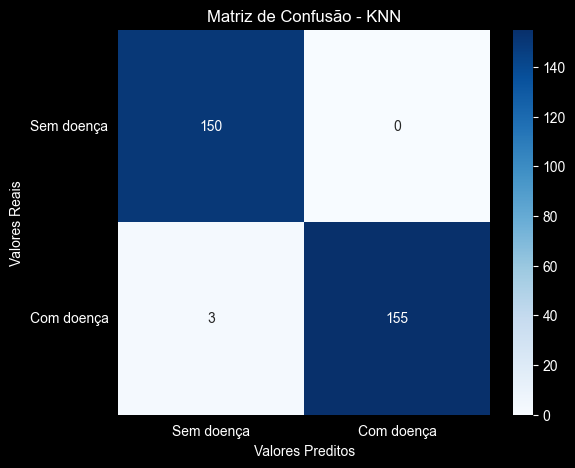

In [103]:
plot_confusion_matrix(
    y_test,
    y_pred_knn,
    'KNN'
)

### Regressão Logística

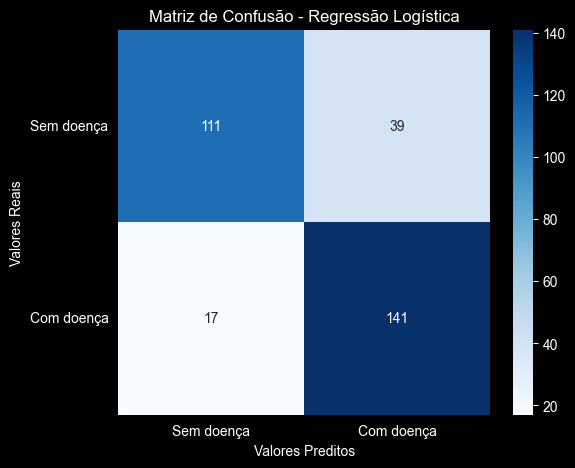

In [104]:
plot_confusion_matrix(
    y_test,
    y_pred_log,
    'Regressão Logística'
)

### Árvore de Decisão

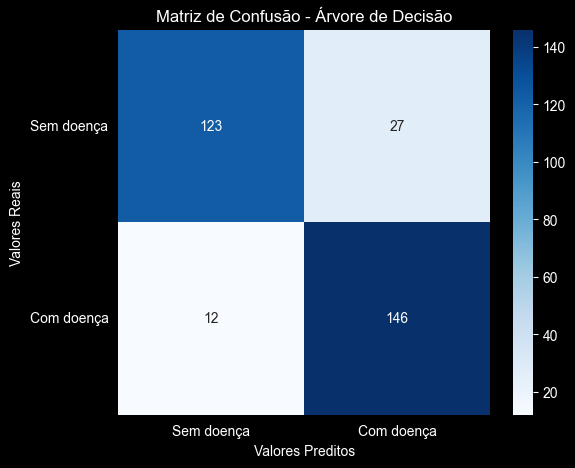

In [105]:
plot_confusion_matrix(
    y_test,
    y_pred_tree,
    'Árvore de Decisão'
)

### Random Forest

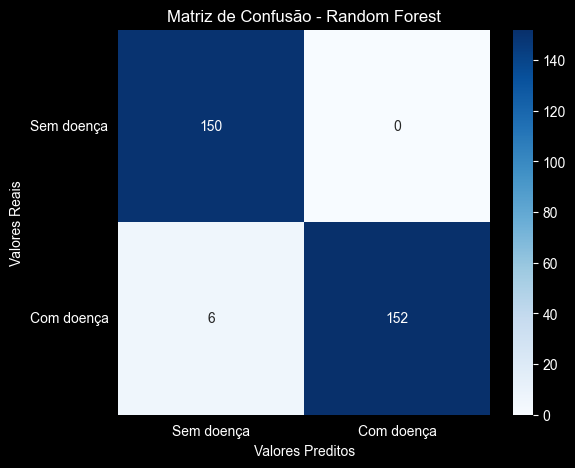

In [106]:
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    'Random Forest'
)

### SVM

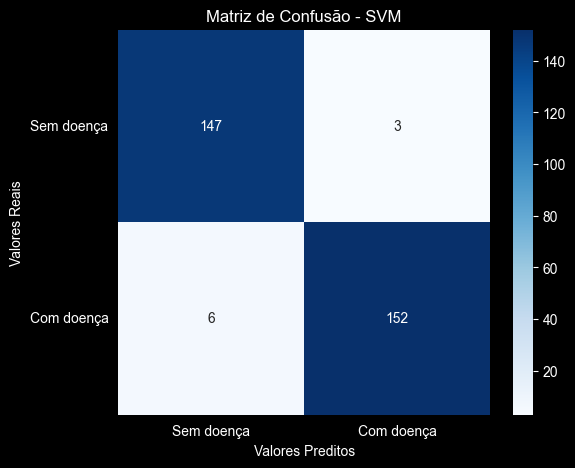

In [107]:
plot_confusion_matrix(
    y_test,
    y_pred_svm,
    'SVM'
)

### Naive Bayes

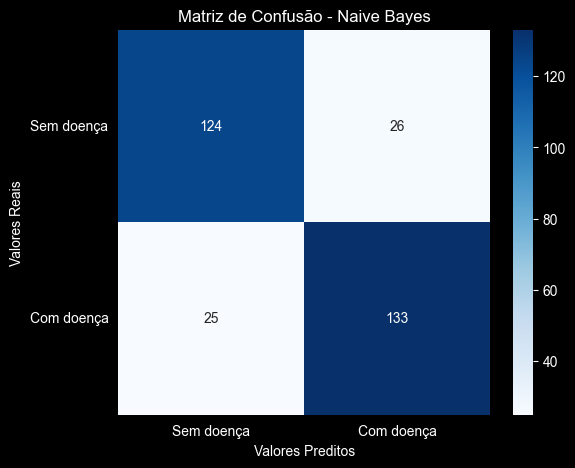

In [108]:
plot_confusion_matrix(
    y_test,
    y_pred_nb,
    'Naive Bayes'
)

## Conclusão das Matrizes confusão

A análise das matrizes de confusão reforça os resultados obtidos pelas métricas de desempenho e evidencia, com maior clareza, o comportamento de cada modelo frente aos dois tipos de erro possíveis: falsos positivos (pacientes saudáveis classificados como doentes) e falsos negativos (pacientes doentes classificados como saudáveis).

O KNN apresentou o melhor desempenho absoluto, com zero falsos positivos e apenas 3 falsos negativos, totalizando somente 3 erros de classificação em todo o conjunto de teste. Esse resultado confirma sua superioridade frente aos demais modelos avaliados.

O Random Forest também zerou os falsos positivos, porém registrou 6 falsos negativos — o dobro do KNN —, indicando que, apesar da precisão máxima, o modelo perdeu mais casos de pacientes doentes do que o KNN.

O SVM apresentou desempenho próximo ao Random Forest, com apenas 3 falsos positivos e 6 falsos negativos, demonstrando boa capacidade de separação entre as classes, com erros bem distribuídos.

A Árvore de Decisão e o Naive Bayes registraram volumes de erro maiores, com destaque negativo para o Naive Bayes, que acumulou 25 falsos negativos e 26 falsos positivos — o pior desempenho entre todos os modelos em termos de erros totais.
A Regressão Logística apresentou o maior número de falsos positivos (39), o que, em um contexto clínico, representaria um alto índice de pacientes saudáveis incorretamente encaminhados para tratamento cardíaco.

Em suma, no contexto de diagnóstico de doenças cardíacas, onde falsos negativos representam o erro mais crítico — pois significam pacientes doentes não identificados —, o KNN se confirma como o modelo mais seguro e eficiente, seguido pelo Random Forest e pelo SVM.

# 8) Discussão e Veredito Final
## Melhor performance global
O modelo com melhor performance global foi o KNN, que alcançou aproximadamente 99% de acurácia, precisão máxima (1.00), Recall de 98,1% e F1-Score de 0.990. Sua superioridade foi confirmada tanto pelas métricas quantitativas quanto pela matriz de confusão, que registrou apenas 3 erros em todo o conjunto de teste — todos falsos negativos — e nenhum falso positivo. O ajuste fino do hiperparâmetro k foi determinante para que o modelo conseguisse generalizar bem sem memorizar os dados de treinamento, resultando em classificações consistentes e confiáveis para ambas as classes.

## Sinais de overfitting

De forma geral, os modelos com maior complexidade — como o Random Forest — tendem naturalmente a apresentar menor risco de overfitting por utilizarem múltiplas árvores de decisão com aleatorização, o que reduz a variância das previsões. O KNN, por sua vez, é sensível à escolha do valor de k: valores muito baixos tendem a memorizar os dados de treino, enquanto valores muito altos suavizam excessivamente as fronteiras de decisão. O desempenho elevado e estável observado no conjunto de teste indica que o k foi adequadamente calibrado, sem sinais evidentes de overfitting. Já a Árvore de Decisão, por sua natureza, é o modelo mais suscetível a esse problema, o que justifica seu desempenho inferior mesmo com controle de profundidade máxima (max_depth).

## Análise dos resíduos e padrão de erros

Com base nas matrizes de confusão, os erros cometidos pelos modelos mais robustos — KNN, Random Forest e SVM — apresentam caráter predominantemente aleatório, sem evidências de viés sistemático em uma das classes. Isso indica que esses modelos capturaram adequadamente as relações entre as variáveis clínicas e a variável alvo. Em contrapartida, a Regressão Logística apresentou um padrão mais desequilibrado, com 39 falsos positivos contra apenas 17 falsos negativos, sugerindo uma tendência sistemática de classificar pacientes saudáveis como doentes — o que pode indicar limitação do modelo em separar linearmente as classes neste dataset.

## Recomendação prática

Considerando o uso prático deste modelo em um ambiente hospitalar ou sistema de apoio ao diagnóstico clínico, a recomendação é pelo KNN como modelo principal, com o Random Forest como alternativa complementar. O KNN apresentou o melhor equilíbrio entre desempenho preditivo e controle de erros críticos, especialmente os falsos negativos, que em contexto médico representam pacientes doentes não identificados — o erro de maior impacto clínico e ético.
O Random Forest, apesar de ligeiramente inferior em acurácia e recall, oferece maior resistência ao overfitting e maior estabilidade em cenários com variação nos dados de entrada, o que o torna uma escolha robusta para ambientes produtivos onde o modelo precisa ser atualizado periodicamente com novos dados.
Modelos mais simples, como a Regressão Logística, seriam recomendados apenas em contextos onde a interpretabilidade seja um requisito prioritário — por exemplo, quando médicos ou gestores precisam compreender quais variáveis mais influenciam a predição para embasar decisões clínicas. Nesse caso, a perda de desempenho (~84% de acurácia) seria o custo pela ganho em transparência e explicabilidade do modelo.
Em síntese, o KNN é o veredito final para este problema, por reunir alta precisão diagnóstica, ausência de falsos positivos e mínimo de falsos negativos — características essenciais para um sistema de suporte à decisão clínica confiável e seguro.

# 9) Referências Bibliográficas

* PEDREGOSA, F. et al. *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, v. 12, p. 2825–2830, 2011.

* MCKINNEY, Wes. *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and Jupyter*. 3. ed. Sebastopol: O'Reilly Media, 2022.

* HARRISON, Matt. *Machine Learning Pocket Reference*. Sebastopol: O'Reilly Media, 2019.

* GERON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2022.

* HASTIE, Trevor; TIBSHIRANI, Robert; FRIEDMAN, Jerome. *The Elements of Statistical Learning*. 2. ed. New York: Springer, 2009.

* SCIKIT-LEARN. Documentation. Disponível em:
  [Scikit-Learn Official Documentation](https://scikit-learn.org/stable/?utm_source=chatgpt.com)

* PANDAS. Documentation. Disponível em:
  [Pandas Official Documentation](https://pandas.pydata.org/docs/?utm_source=chatgpt.com)

* NUMPY. Documentation. Disponível em:
  [NumPy Official Documentation](https://numpy.org/doc/?utm_source=chatgpt.com)

* MATPLOTLIB. Documentation. Disponível em:
  [Matplotlib Official Documentation](https://matplotlib.org/stable/contents.html?utm_source=chatgpt.com)

* SEABORN. Documentation. Disponível em:
  [Seaborn Official Documentation](https://seaborn.pydata.org/?utm_source=chatgpt.com)

* PLOTLY. Documentation. Disponível em:
  [Plotly Official Documentation](https://plotly.com/python/?utm_source=chatgpt.com)

* UCI MACHINE LEARNING REPOSITORY. *Heart Disease Dataset*. Disponível em:
  [UCI Heart Disease Dataset](https://archive.ics.uci.edu/ml/datasets/heart+Disease?utm_source=chatgpt.com)
